In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import os
import re
import zarr
from tqdm import tqdm

In [ ]:
data = zarr.open_group('harps_data.zarr')
data.tree()

/
├── bjds (22,) float64
├── continuum (22, 313193) float64
├── errors (22, 313193) float32
├── exptimes (22,) float64
├── fluxes (22, 313193) float32
├── mjd_ends (22,) float64
├── mjd_starts (22,) float64
├── normalized_flux (22, 313193) float64
├── normalized_wave (22, 313193) float64
├── phases (22,) float64
├── snrs (22,) float64
└── wavelengths (22, 313193) float64

In [ ]:
data['bjds'][:]

array([2456879.93638232, 2456876.93959495, 2456214.87742754,
       2456878.94000377, 2456242.5188001 , 2456578.90879858,
       2455534.52627444, 2455060.75795559, 2455504.6389956 ,
       2456877.93335813, 2454887.5473123 , 2455144.75572815,
       2457029.52876622, 2456577.90650648, 2456213.85143274,
       2455431.81043432, 2457005.52317917, 2456213.69080592,
       2455479.60775989, 2455536.51977833, 2456552.84900291,
       2456908.81522063])

In [ ]:
T_0 = 2445183.92451
P = 75.666

In [ ]:
data.create_array('phases', data=(data['bjds'][:] - T_0) % P, overwrite=True)

<Array file://harps_data.zarr/phases shape=(22,) dtype=float64>

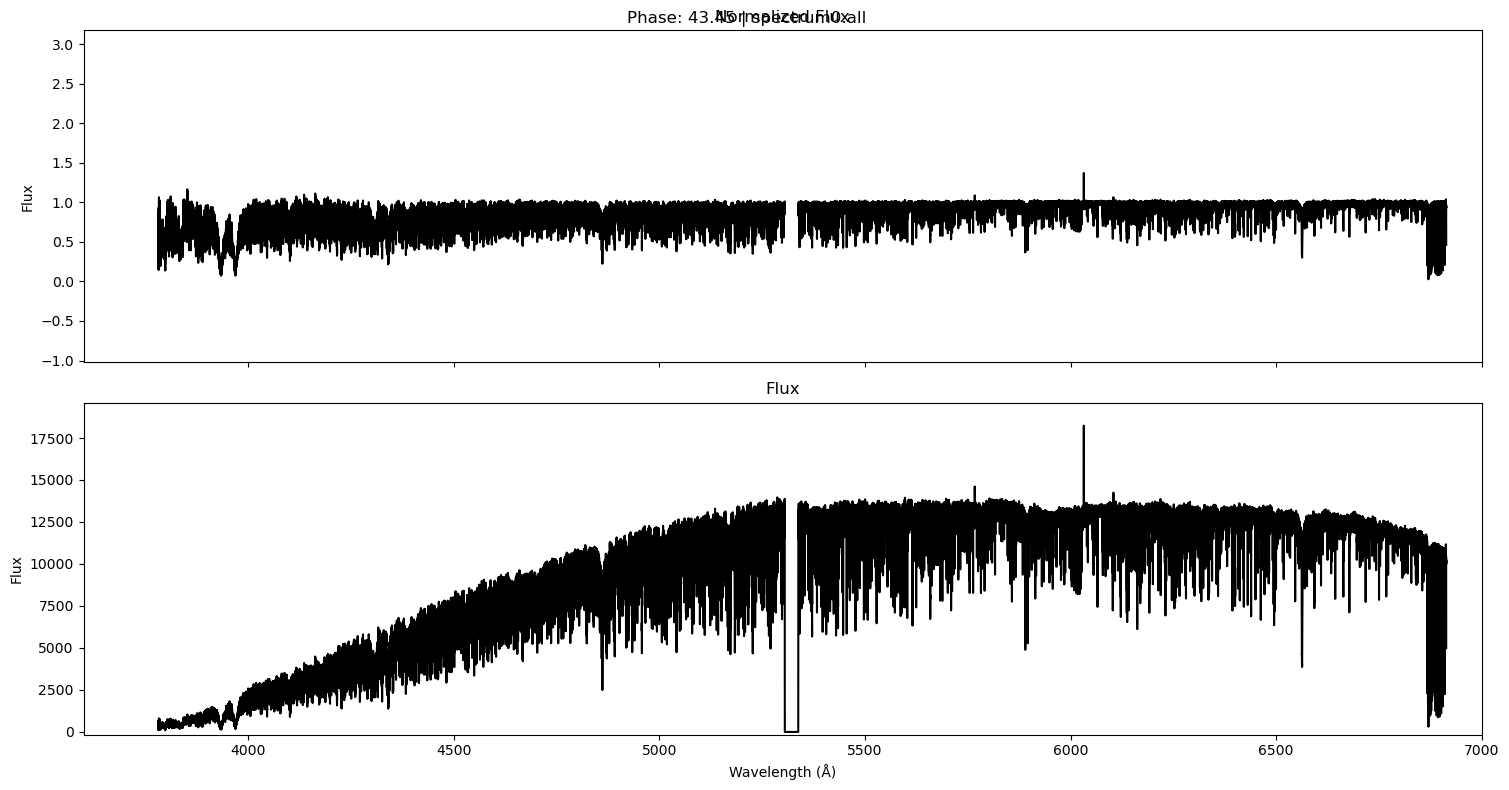

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

def spectrum_index_from_name(filename):
    match = re.search(r'spectrum(\d+)\.all$', filename)
    return int(match.group(1)) if match else None

def mask_zero_only_gap(values):
    values = np.array(values, dtype=float, copy=True)
    values[values == 0] = np.nan
    return values

source_files = data.attrs.get('normalized_flux_source_files', [])
normalized_row_for_exposure = {}
for row, name in enumerate(source_files):
    exposure_index = spectrum_index_from_name(name)
    if exposure_index is not None:
        normalized_row_for_exposure[exposure_index] = row

def normalized_row_index(exposure_index):
    return normalized_row_for_exposure.get(exposure_index, exposure_index)

def normalized_series(exposure_index):
    row = normalized_row_index(exposure_index)
    wave = np.array(data['normalized_wave'][row], dtype=float, copy=False)
    flux = mask_zero_only_gap(data['normalized_flux'][row])
    return wave, flux, row

def title_for_exposure(exposure_index):
    row = normalized_row_index(exposure_index)
    source_file = source_files[row] if row < len(source_files) else None
    title = f"Phase: {data['phases'][exposure_index]:.2f}"
    return f"{title} | {source_file}" if source_file else title

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

num_exposures = data['phases'].shape[0]

line1, = axes[0].plot([], [], color='black')
line2, = axes[1].plot([], [], color='black')

axes[0].set_title('Normalized Flux')
axes[0].set_ylabel('Flux')

axes[1].set_title('Flux')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylabel('Flux')

fig.tight_layout()

finite_norm_chunks = []
for i in range(num_exposures):
    _, norm_flux, _ = normalized_series(i)
    finite = norm_flux[np.isfinite(norm_flux)]
    if finite.size:
        finite_norm_chunks.append(finite)

if not finite_norm_chunks:
    raise ValueError('All normalized spectra are empty after masking the zero-only gap.')

all_norm = np.concatenate(finite_norm_chunks)
all_flux = data['fluxes'][:].astype(float)
all_flux = all_flux[np.isfinite(all_flux)]

# --- find a valid exposure to initialize ---
valid_idx = None
for i in range(num_exposures):
    raw_wave = np.array(data['wavelengths'][i], dtype=float, copy=False)
    _, norm_flux, _ = normalized_series(i)
    if np.isfinite(raw_wave).any() and np.isfinite(norm_flux).any():
        valid_idx = i
        break

if valid_idx is None:
    raise ValueError("All wavelength arrays are empty!")

wave0, norm0, _ = normalized_series(valid_idx)
raw_wave0 = np.array(data['wavelengths'][valid_idx], dtype=float, copy=False)
flux0 = np.array(data['fluxes'][valid_idx], dtype=float, copy=False)

# Set static axis limits
axes[0].set_xlim(3600, 7000)
axes[1].set_xlim(3600, 7000)

axes[0].set_ylim(np.nanmin(all_norm), np.nanmax(all_norm))
axes[1].set_ylim(np.nanmin(all_flux), np.nanmax(all_flux))


def init():
    line1.set_data(wave0, norm0)
    line2.set_data(raw_wave0, flux0)
    fig.suptitle(title_for_exposure(valid_idx))
    return line1, line2


def update(i):

    wave = np.array(data['wavelengths'][i], dtype=float, copy=False)

    if not np.isfinite(wave).any():
        return line1, line2

    norm_wave, norm_flux, _ = normalized_series(i)
    flux = np.array(data['fluxes'][i], dtype=float, copy=False)

    line1.set_data(norm_wave, norm_flux)
    line2.set_data(wave, flux)

    fig.suptitle(title_for_exposure(i))

    return line1, line2


frames = range(num_exposures)

anim = FuncAnimation(
    fig,
    update,
    frames=frames,
    init_func=init,
    blit=False,
    interval=600
)

writer = PillowWriter(fps=2)
anim.save("phase_harps.gif", writer=writer)

In [ ]:
i = 10
norm_row = normalized_row_index(i)
source_files[norm_row] if source_files else f'normalized row {norm_row}'

'spectrum10.all'

Text(0.5, 1.0, 'spectrum10.all')

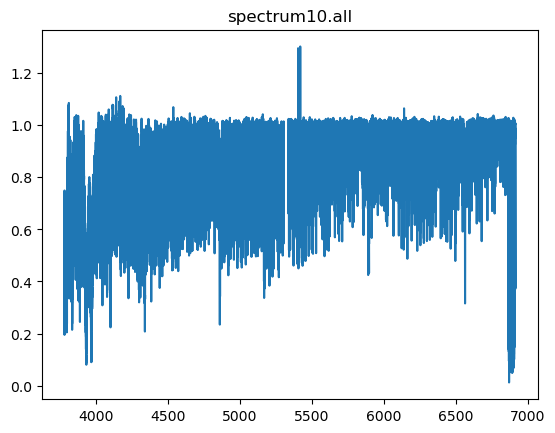

In [ ]:
i = 10
norm_wave, norm_flux, norm_row = normalized_series(i)
plt.plot(norm_wave, norm_flux)
plt.title(source_files[norm_row] if source_files else f'normalized row {norm_row}')